In [1]:
import json
import numpy as np 
from matplotlib import pyplot as plt

In [2]:
def read_data(model_name, dataset_name, layer, basis_name):
    
    with open(f"../../artifacts/2024-10-s41/experiments/accuracy-basis/run2-refinement/{dataset_name}/{model_name}/{layer}/{basis_name}--uncentered/accuracy.json", "r") as fh:
        return json.load(fh)

read_data(model_name="cifar100-resnet18-v1", dataset_name="cifar100-people-and-others", layer="layer1", basis_name="pca")

{'accuracies': [0.949999988079071,
  0.949999988079071,
  0.9531000256538391,
  0.9607999920845032,
  0.9638000130653381,
  0.96670001745224,
  0.9689000248908997,
  0.9729999899864197,
  0.9746999740600586,
  0.9750000238418579,
  0.9754999876022339,
  0.9754999876022339,
  0.9753999710083008,
  0.9750999808311462,
  0.9754999876022339,
  0.9753000140190125,
  0.9750999808311462,
  0.9746999740600586],
 'arr_ks': [1, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 64],
 'aurocs': [[0.5166884064674377,
   0.5067605972290039,
   0.5040773153305054,
   0.5003969669342041,
   0.5074575543403625,
   0.5055254697799683],
  [0.505935788154602,
   0.5769848823547363,
   0.5447267889976501,
   0.5087515115737915,
   0.5432111024856567,
   0.5399092435836792],
  [0.7927236557006836,
   0.6889950037002563,
   0.7976539731025696,
   0.8550757169723511,
   0.852776825428009,
   0.8369064331054688],
  [0.914176344871521,
   0.8317707180976868,
   0.8899328112602234,
   0.929226219654083

In [3]:
read_data(model_name="cifar100-resnet18-v1", dataset_name="cifar100-people-and-others", layer="layer2", basis_name="prca-sortabs")

{'accuracies': [0.949999988079071,
  0.949999988079071,
  0.949999988079071,
  0.9502000212669373,
  0.953000009059906,
  0.9545000195503235,
  0.9577999711036682,
  0.9577999711036682,
  0.9562000036239624,
  0.9603999853134155,
  0.9677000045776367,
  0.9728000164031982,
  0.9731000065803528,
  0.9732000231742859,
  0.9742000102996826,
  0.9760000109672546,
  0.9754999876022339,
  0.9761000275611877,
  0.9764000177383423,
  0.9754999876022339,
  0.9757999777793884,
  0.9753999710083008,
  0.9753000140190125,
  0.9746999740600586,
  0.9742000102996826,
  0.9742000102996826,
  0.9746999740600586,
  0.9745000004768372,
  0.9743000268936157,
  0.9745000004768372,
  0.974399983882904,
  0.9745000004768372,
  0.974399983882904,
  0.9746999740600586],
 'arr_ks': [1,
  2,
  4,
  6,
  8,
  10,
  12,
  14,
  16,
  18,
  20,
  22,
  24,
  26,
  28,
  30,
  32,
  34,
  36,
  38,
  40,
  42,
  44,
  46,
  48,
  50,
  52,
  54,
  56,
  58,
  60,
  62,
  64,
  128],
 'aurocs': [[0.6893904209136963,

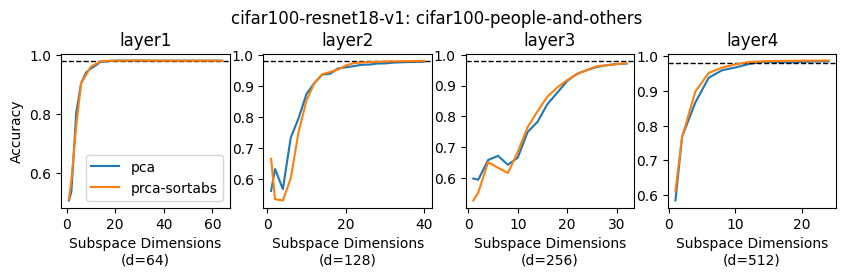

In [14]:
def viz(model_name, dataset_name, arr_layers=["layer2", "layer3", "layer4:20"]):
    ncols = len(arr_layers)
    
    
    plt.figure(figsize=(2.5*ncols, 2))
    plt.suptitle(f"{model_name}: {dataset_name}", y=1.10)
    
    for lix, layer in enumerate(arr_layers):
        plt.subplot(1, ncols, lix +1)
        slugs = layer.split(":")
        if len(slugs) == 2:
            layer, K = slugs
            K = int(K)
        else:
            layer = slugs[0]
            K = None
        plt.title(layer)
        if lix == 0:
            plt.ylabel("Accuracy")
#         print(f"layer: {layer}")
        for bix, basis_name in enumerate(["pca", "prca-sortabs"]):
            data = read_data(model_name, dataset_name, layer, basis_name)
            arr_ks = np.array(data["arr_ks"])
        
            d = arr_ks[-1]
#             arr_accs = np.array(data["accuracies"])
            arr_accs = np.array(data["aurocs"]).mean(axis=1)
            best_acc = arr_accs[-1]
        
        
            if K is not None:
                selected = arr_ks <= K
                arr_ks = arr_ks[selected]
                arr_accs = arr_accs[selected]
                
#             print(arr_accs)
            plt.plot(arr_ks, arr_accs, label=basis_name)
            if bix == 0:
                plt.axhline(best_acc, ls="--", lw=1, color="k")
        plt.xlabel(f"Subspace Dimensions\n(d={d})")
        if lix == 0:
            plt.legend()

viz("cifar100-resnet18-v1", "cifar100-people-and-others", arr_layers=["layer1", "layer2:40", "layer3:32", "layer4:24"])

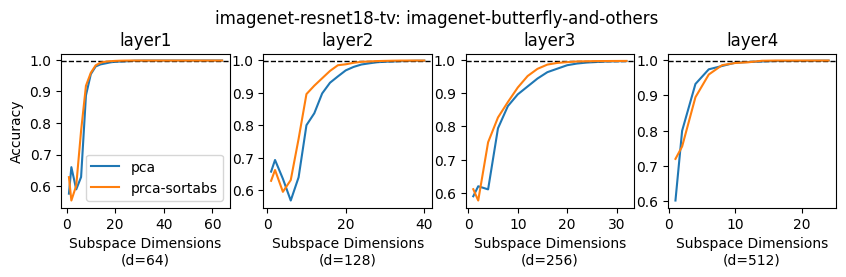

In [15]:
viz("imagenet-resnet18-tv", "imagenet-butterfly-and-others", arr_layers=["layer1", "layer2:40", "layer3:32", "layer4:24"])

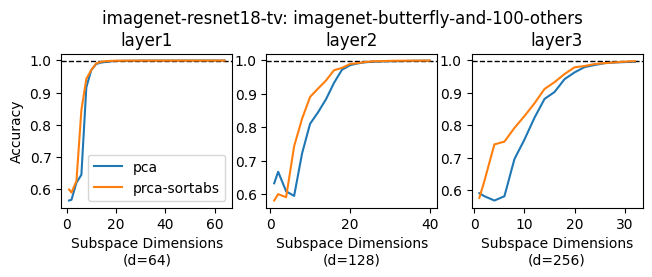

In [16]:
viz("imagenet-resnet18-tv", 
    "imagenet-butterfly-and-100-others", 
    arr_layers=["layer1", "layer2:40", "layer3:32", "layer4:24"][:3]
)